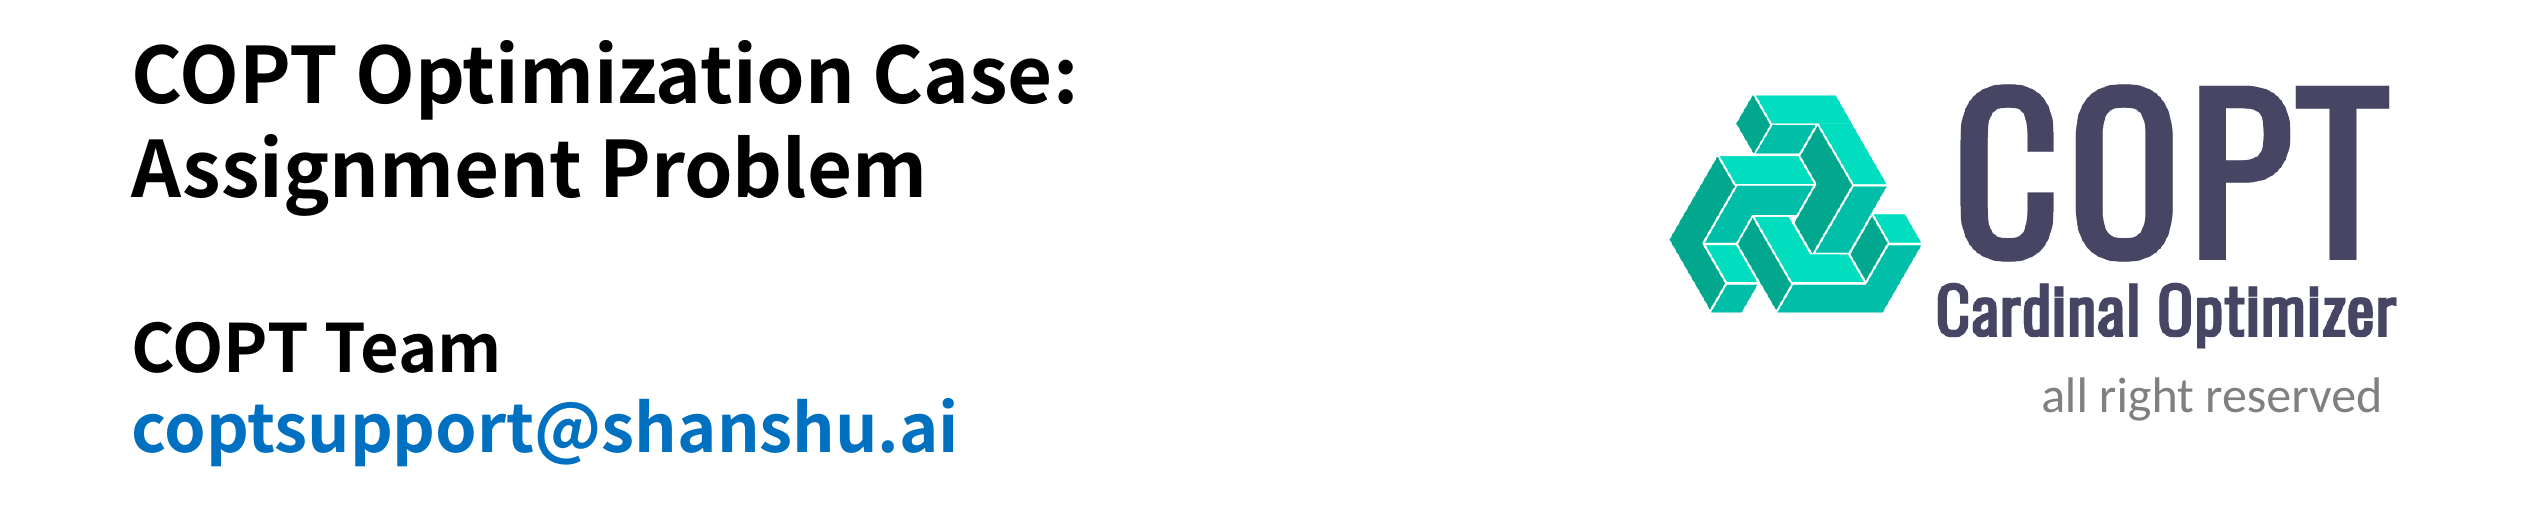

> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib


# Assignment Problem Code Implementation
## Steps to Model and Solve the Assignment Problem Using COPT

1. **Import the COPT-Python API** `coptpy`, together with `matplotlib` for plotting

2. **Add model data**: consultants, projects, and the working days each consultant needs for each project

3. **Create the COPT environment and model**

4. **Build the model: add the three core components in turn**
    - **Decision variables**:
        - $x_{ij}$: 0-1 variable, equal to 1 if consultant $i$ is assigned to project $j$
    - **Objective function**: minimize the total number of working days
    - **Constraints**:
        - Each consultant is assigned exactly one project
        - Each project is assigned exactly one consultant

5. **Solve**

6. **Retrieve and analyze the results**: print the assignment, compare it with a rule of thumb, and verify the integrality of the LP relaxation

7. **Case expansion**
    - Unbalanced assignment: more projects than consultants, at most two projects per consultant
    - Bottleneck assignment: minimize the longest duration first, then the total workload

The mathematical model and the meaning of each symbol are given in the case description; the code below follows the steps above.

## Import COPT-Python API
Besides `coptpy`, `matplotlib` is imported for plotting.

In [1]:
import coptpy as cp
from coptpy import COPT

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Heat map colors: light to medium blue, so that the numbers stay readable
LIGHT_BLUES = LinearSegmentedColormap.from_list('light_blues', ['#eef4fb', '#5d9be3'])

## Add Model Data
Five consultants, five projects, and the working days each consultant needs for each project. The table is stored as a dictionary `days` keyed by (consultant, project): `days['A', 'P3']` is the number of days A needs for P3, i.e. $c_{ij}$ in the mathematical model.

In [2]:
consultants = ['A', 'B', 'C', 'D', 'E']
projects = ['P1', 'P2', 'P3', 'P4', 'P5']

# Working days c_ij each consultant needs for each project
days_table = [
    [10, 18, 16, 19, 15],
    [ 8, 12, 18, 19, 14],
    [13, 13, 15, 10,  9],
    [ 8,  9, 12,  9, 13],
    [14,  9, 16, 20, 11],
]
days = {(i, j): days_table[a][b] for a, i in enumerate(consultants) for b, j in enumerate(projects)}

## Create the COPT Environment and COPT Model
Modeling with COPT starts by creating an environment `Envr` and then a model object `Model` inside it; all variables and constraints are added to this model.

In [3]:
env = cp.Envr()
model = env.createModel("assignment")

Cardinal Optimizer v8.0.6. Build date Aug  7 2026
Copyright Cardinal Operations 2026. All Rights Reserved


## Add three core components of COPT Model

### Add Decision Variables
Each consultant-project pair gets a 0-1 variable $x_{ij}$. Passing both the consultant list and the project list to `addVars()` creates one variable for every combination, indexed by the pair `(consultant, project)`.

In [4]:
x = model.addVars(consultants, projects, vtype=COPT.BINARY, nameprefix='x')

print(f'{len(x)} variables created, e.g. x["A", "P3"] is named {x["A", "P3"].name}')

25 variables created, e.g. x["A", "P3"] is named x(A,P3)


<font color=#0000FF>
<b>Tip: Creating variables over several index sets</b>
</font>

`Model.addVars()` accepts several iterables as index sets and returns a `tupledict` whose keys are the combinations (tuples) of their elements, here `('A', 'P1')`, `('A', 'P2')`, …, $5 \times 5 = 25$ keys in total. Variable names are built from `nameprefix` and the index, giving `x(A,P3)` and so on, which match the $x_{ij}$ of the mathematical model one to one.

`vtype=COPT.BINARY` declares 0-1 variables, equivalent to integer variables bounded by $[0, 1]$.

### Set Objective Function
The objective is the smallest total number of working days. The `prod()` method of a `tupledict` multiplies each variable by the coefficient with the same key and adds the products, so `x.prod(days)` is $\sum_{i,j} c_{ij} x_{ij}$.
$$
\min \, \sum_{i \in I} \sum_{j \in J} c_{ij} \cdot x_{ij}
$$

In [5]:
model.setObjective(x.prod(days), sense=COPT.MINIMIZE)

### Add Constraints
Two groups of constraints: each consultant takes exactly one project, and each project is taken by exactly one consultant. `x.sum(i, '*')` adds up all variables of consultant $i$ (`'*'` means "any value" in that index position), and `x.sum('*', j)` does the same for project $j$.
$$
\sum_{j \in J} x_{ij} = 1, \quad \forall \, i \in I \qquad\qquad \sum_{i \in I} x_{ij} = 1, \quad \forall \, j \in J
$$

In [6]:
consultant_cons = model.addConstrs((x.sum(i, '*') == 1 for i in consultants), nameprefix='consultant')
project_cons = model.addConstrs((x.sum('*', j) == 1 for j in projects), nameprefix='project')

print(f'Model size: {model.getAttr("Rows")} rows (constraints), {model.getAttr("Cols")} columns (variables)')

Model size: 10 rows (constraints), 25 columns (variables)


<font color=#0000FF>
<b>Tip: sum() and prod() of a tupledict</b>
</font>

Besides indexing, the `tupledict` returned by `addVars()` offers two aggregation methods:

- `x.sum(i, '*')` adds up the variables whose first index is `i` and whose second index is arbitrary, returning a linear expression; `x.sum()` without arguments adds up all variables. For variables organized along several dimensions this is shorter than `quicksum(x[i, j] for j in projects)` and less prone to index mistakes.
- `x.prod(coeff)` forms the weighted sum of the variables with the dictionary `coeff` as coefficients, where the keys of `coeff` match the variable indices. The objective $\sum c_{ij} x_{ij}$ becomes the single call `x.prod(days)`.

`Model.addConstrs()` takes a generator expression and adds one constraint per item; `nameprefix` produces constraint names such as `consultant(A)`.

### Inspect the Model File
Once the model is built, it can be exported as a text file in LP format. An LP file lists the objective, the constraints and the variable types in a notation close to the mathematical formulas, which is the most direct way to check that the model matches what was intended.

In [7]:
model.write('assignment.lp')

with open('assignment.lp') as f:
    print(f.read())

\Generated by Cardinal Operations

Minimize
   10 x(A,P1) + 18 x(A,P2) + 16 x(A,P3) + 19 x(A,P4) + 15 x(A,P5) 
   + 8 x(B,P1) + 12 x(B,P2) + 18 x(B,P3) + 19 x(B,P4) + 14 x(B,P5) 
   + 13 x(C,P1) + 13 x(C,P2) + 15 x(C,P3) + 10 x(C,P4) + 9 x(C,P5) 
   + 8 x(D,P1) + 9 x(D,P2) + 12 x(D,P3) + 9 x(D,P4) + 13 x(D,P5) 
   + 14 x(E,P1) + 9 x(E,P2) + 16 x(E,P3) + 20 x(E,P4) + 11 x(E,P5) 
Subject To
 consultant(A): x(A,P1) + x(A,P2) + x(A,P3) + x(A,P4) + x(A,P5) = 1
 consultant(B): x(B,P1) + x(B,P2) + x(B,P3) + x(B,P4) + x(B,P5) = 1
 consultant(C): x(C,P1) + x(C,P2) + x(C,P3) + x(C,P4) + x(C,P5) = 1
 consultant(D): x(D,P1) + x(D,P2) + x(D,P3) + x(D,P4) + x(D,P5) = 1
 consultant(E): x(E,P1) + x(E,P2) + x(E,P3) + x(E,P4) + x(E,P5) = 1
 project(P1): x(A,P1) + x(B,P1) + x(C,P1) + x(D,P1) + x(E,P1) = 1
 project(P2): x(A,P2) + x(B,P2) + x(C,P2) + x(D,P2) + x(E,P2) = 1
 project(P3): x(A,P3) + x(B,P3) + x(C,P3) + x(D,P3) + x(E,P3) = 1
 project(P4): x(A,P4) + x(B,P4) + x(C,P4) + x(D,P4) + x(E,P4) = 1
 pro

<font color=#0000FF>
<b>Tip: Exporting the model with Model.write()</b>
</font>

`Model.write(filename)` chooses the format from the file extension: `.lp` is the most readable LP format, `.mps` is the MPS format shared by most solvers, and `.bin` is COPT's own binary format; after solving, `.sol` exports the solution and `.bas` the basis. The exported LP file shows the 25 variables split across the two groups of constraints with all coefficients equal to 1, and the variable and constraint names generated by `nameprefix`.

When debugging a model, exporting the LP file and checking it against the mathematical formulation often reveals modeling errors faster than inspecting the solution.

## Solve

In [8]:
model.solve()

Model fingerprint: 2624400

Using Cardinal Optimizer v8.0.6 on Linux (Ubuntu 24.04.4 LTS - x86_64)
The CPU model is Intel(R) Xeon(R) Processor @ 2.80GHz
Hardware has 2 physical cores and 2 logical cores. Using instruction set X86_AVX512_E1 (14)
Minimizing a MIP problem

The original problem has:
    10 rows, 25 columns and 50 non-zero elements
    25 binaries

Starting the MIP solver with 2 threads and 4 tasks

Presolving the problem

The presolved problem has:
    10 rows, 25 columns and 50 non-zero elements
    25 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,1e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [8e+00,2e+01]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  0.000000e+00            --     Inf  0.01s
H        0         1      --       0  0.0

<font color=#0000FF>
<b>Tip: How to read the COPT solver log</b>
</font>

The log begins with the model size (`10 rows, 25 columns`, 25 binaries) and the size after presolving. For an integer program the core of the log is the branch-and-bound table: `BestBound` is the lower bound proven so far, `BestSolution` is the best integer solution found so far, and `Gap` is their relative difference; a gap of 0 proves optimality.

In this log the LP relaxation at the root node is already integer, so branch and bound does not need to explore any further nodes. This is the integrality property of the assignment problem described in the case description. `Solution status : integer optimal` at the end confirms an optimal integer solution; in code this corresponds to `model.status == COPT.OPTIMAL`.

## Retrieve Results
After the solve, the attribute `x[i, j].x` holds the value of each variable in the optimal solution (it has no meaning before solving); the pairs with value 1 form the assignment, and `model.objval` gives the optimal objective value. The assignment is printed first and then drawn as a heat map. Each cell corresponds to one consultant-project pair and shows the required working days; the darker the blue, the more days are needed (the color bar on the right gives the scale). Orange cells mark the selected pairs, exactly one per row and one per column. The heat maps later in the notebook use the same convention. For comparison, the rule of thumb from the case description is computed as well: go through the consultants in order and let each pick the fastest project still available.

Rule of thumb (each consultant picks the fastest remaining project):
  A -> P1: 10 working days
  B -> P2: 12 working days
  C -> P5: 9 working days
  D -> P4: 9 working days
  E -> P3: 16 working days
  Total: 56 working days

COPT optimal assignment:
  A -> P3: 16 working days
  B -> P1: 8 working days
  C -> P5: 9 working days
  D -> P4: 9 working days
  E -> P2: 9 working days
  Total: 51 working days


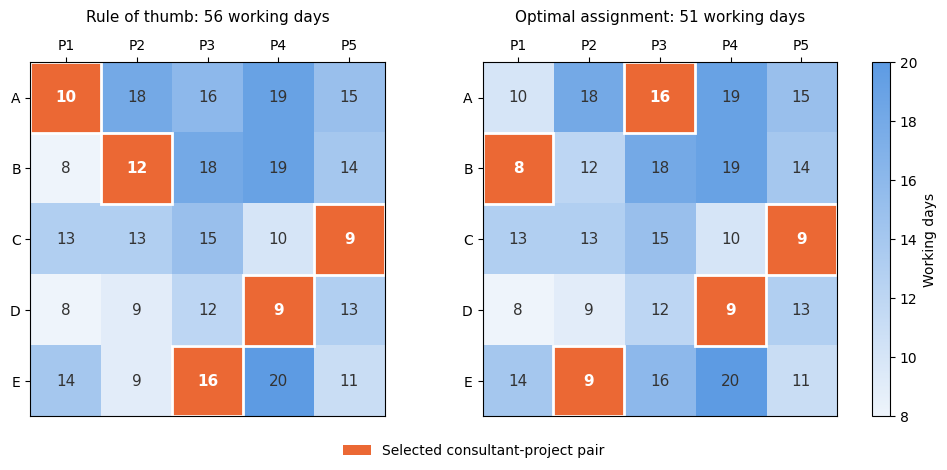

In [9]:
def get_assignment(x):
    """Read the assignment from the variable values; returns {consultant: [projects]}"""
    result = {}
    for (i, j), var in x.items():
        if var.x > 0.5:
            result.setdefault(i, []).append(j)
    return result


def print_assignment(assignment, days, title):
    total = 0
    print(title)
    for i in consultants:
        for j in assignment.get(i, []):
            print(f'  {i} -> {j}: {days[i, j]} working days')
            total += days[i, j]
        if not assignment.get(i):
            print(f'  {i} -> none')
    print(f'  Total: {total} working days\n')
    return total


def plot_assignment(ax, days, rows, cols, assignment, title):
    """Heat map of working days with the selected consultant-project pairs highlighted"""
    matrix = [[days[i, j] for j in cols] for i in rows]
    im = ax.imshow(matrix, cmap=LIGHT_BLUES, vmin=min(map(min, matrix)), vmax=max(map(max, matrix)))
    for a, i in enumerate(rows):
        for b, j in enumerate(cols):
            if j in assignment.get(i, []):
                ax.add_patch(plt.Rectangle((b - 0.5, a - 0.5), 1, 1, facecolor='#eb6834', edgecolor='white', linewidth=2))
                ax.text(b, a, str(days[i, j]), ha='center', va='center', fontsize=11, color='white', fontweight='bold')
            else:
                ax.text(b, a, str(days[i, j]), ha='center', va='center', fontsize=11, color='#333333')
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(rows)
    ax.xaxis.set_ticks_position('top')
    ax.set_title(title, fontsize=11, pad=12)
    return im


# Rule of thumb: each consultant in turn picks the fastest project still available
remaining = list(projects)
greedy = {}
for i in consultants:
    j = min(remaining, key=lambda p: days[i, p])
    greedy[i] = [j]
    remaining.remove(j)

if model.status == COPT.OPTIMAL:
    optimal = get_assignment(x)
    total_greedy = print_assignment(greedy, days, 'Rule of thumb (each consultant picks the fastest remaining project):')
    total_opt = print_assignment(optimal, days, 'COPT optimal assignment:')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))
    plot_assignment(ax1, days, consultants, projects, greedy, f'Rule of thumb: {total_greedy} working days')
    im = plot_assignment(ax2, days, consultants, projects, optimal, f'Optimal assignment: {total_opt} working days')
    fig.colorbar(im, ax=[ax1, ax2], fraction=0.03, pad=0.04, label='Working days')
    fig.legend([plt.Rectangle((0, 0), 1, 1, facecolor='#eb6834')], ['Selected consultant-project pair'],
               loc='lower center', frameon=False)
    plt.show()
else:
    print('No optimal solution found, status:', model.status)

The optimal assignment takes 51 working days, 5 fewer than the 56 of the rule of thumb. The two heat maps show where the difference comes from. Under the rule of thumb the first four consultants all get their fastest projects and P3 is left to E (16 days), who is far from the fastest at it. The optimal plan gives P3 to A instead (16 days, although A is not the fastest at P3 either) and in return B, C, D and E all receive projects of 8 or 9 days. The extra time spent by A is more than offset by the time saved by the other four; this is the difference between a global optimum and a chain of local ones.

The heat map also shows that none of the five selected cells is the largest in its row or column, but not every one is the smallest in its row either. The optimum minimizes the sum, not each individual step.

### Verify the Integrality of the LP Relaxation
The case description states that the LP relaxation of the assignment problem always has an integer solution. Below, the 25 variables are switched from binary to continuous (with range $[0, 1]$) and the same model is solved again to see whether the solution is still 0-1.

In [10]:
for var in model.getVars():
    var.setType(COPT.CONTINUOUS)

model.setParam("Logging", 0)
model.solve()

values = sorted(var.x for var in model.getVars())
print(f'Objective of the LP relaxation: {model.objval}')
print(f'Values of the 25 variables in the optimal solution: {[round(v, 4) for v in values]}')
print('Relaxed solution equals the integer assignment:', get_assignment(x) == optimal)

# Restore binary variables; the extensions below build on the integer model
for var in model.getVars():
    var.setType(COPT.BINARY)

Objective of the LP relaxation: 51.0
Values of the 25 variables in the optimal solution: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Relaxed solution equals the integer assignment: True


<font color=#0000FF>
<b>Tip: Changing variable types with Var.setType()</b>
</font>

`Var.setType()` changes the type of a variable after the model has been built; the options are `COPT.CONTINUOUS`, `COPT.INTEGER` and `COPT.BINARY`. Switching integer variables to continuous and solving again is a manual LP relaxation; switching them back restores the original model without rebuilding it.

`setParam("Logging", 0)` turns off the solver log here. COPT parameter names can be given as plain strings and are case-insensitive.

The LP relaxation also has an objective of 51, all 25 variables are still 0 or 1, and the assignment is identical to that of the integer model. For the assignment problem the integrality requirement is effectively redundant: the optimal vertex of the linear program is already a valid assignment. This is also why the solver log showed an integer solution at the root node.

## Case Expansion 1: Unbalanced Assignment
The firm takes on a sixth project P6, which the five consultants would need 12, 17, 11, 15 and 14 working days to complete, and allows a consultant to handle at most two projects. Compared with the standard model, only the consultant-side constraint changes from "exactly 1" to "at most 2".

In [11]:
projects6 = projects + ['P6']
days6 = dict(days)
for i, d in zip(consultants, [12, 17, 11, 15, 14]):
    days6[i, 'P6'] = d

model6 = env.createModel("unbalanced_assignment")
model6.setParam("Logging", 0)
x6 = model6.addVars(consultants, projects6, vtype=COPT.BINARY, nameprefix='x')
model6.setObjective(x6.prod(days6), sense=COPT.MINIMIZE)
model6.addConstrs((x6.sum(i, '*') <= 2 for i in consultants), nameprefix='consultant')
model6.addConstrs((x6.sum('*', j) == 1 for j in projects6), nameprefix='project')
model6.solve()

assign_le2 = get_assignment(x6)
total_le2 = print_assignment(assign_le2, days6, 'At most two projects per consultant:')

At most two projects per consultant:
  A -> none
  B -> P1: 8 working days
  C -> P5: 9 working days
  C -> P6: 11 working days
  D -> P3: 12 working days
  D -> P4: 9 working days
  E -> P2: 9 working days
  Total: 58 working days


The plan with the smallest workload gives C and D two projects each and leaves A without any. From an efficiency standpoint this is reasonable, since A is the slowest on most projects, but leaving a consultant completely idle is rarely acceptable from a team-management standpoint. Below, a set of constraints requiring every consultant to take at least one project is added to the same model to see how much total workload this costs.

At most two and at least one project per consultant:
  A -> P6: 12 working days
  B -> P1: 8 working days
  C -> P5: 9 working days
  D -> P3: 12 working days
  D -> P4: 9 working days
  E -> P2: 9 working days
  Total: 59 working days


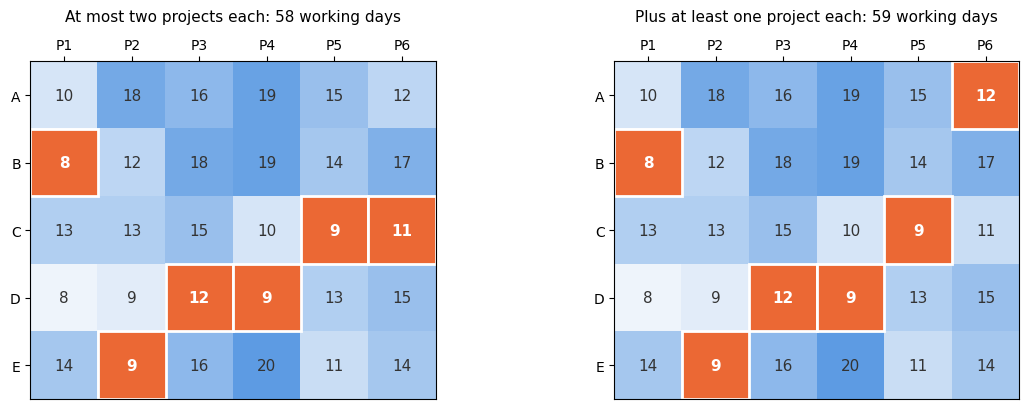

In [12]:
model6.addConstrs((x6.sum(i, '*') >= 1 for i in consultants), nameprefix='at_least_one')
model6.solve()

assign_ge1 = get_assignment(x6)
total_ge1 = print_assignment(assign_ge1, days6, 'At most two and at least one project per consultant:')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
plot_assignment(ax1, days6, consultants, projects6, assign_le2, f'At most two projects each: {total_le2} working days')
plot_assignment(ax2, days6, consultants, projects6, assign_ge1, f'Plus at least one project each: {total_ge1} working days')
plt.tight_layout()
plt.show()

<font color=#0000FF>
<b>Tip: Adding constraints to a solved model</b>
</font>

`Model.addConstrs()` can be called after the model has been solved; the new constraints join the existing model and another `solve()` produces the updated result without rebuilding anything. This suits analyses in which management requirements are added to a baseline plan one at a time and the cost of each is measured: here, adding one group of constraints and solving again gives the plan with at least one project per consultant, ready to be compared with the previous one.

With the requirement of at least one project per consultant, A takes P6 (12 days), the other assignments stay the same, and the total workload rises from 58 to 59 days. Involving every member of the team therefore costs a single working day. The cost of a management requirement is quantified in exactly this way: add the constraint to the model and compare the objective values before and after.

## Case Expansion 2: Bottleneck Assignment
If the five projects start at the same time, the client cares about when the last one is finished, so the objective becomes minimizing the maximum project duration. Following the formulation in the case description, an auxiliary variable $z$ represents the longest duration and $z \geq c_{ij} x_{ij}$ is required for every pair.

With $z$ alone as the objective there may be several optimal plans with different total workloads. COPT's hierarchical multi-objective feature is used to state both objectives: the longest duration $z$ with the higher priority and the total workload with the lower one. The solver first pushes $z$ to its minimum and then minimizes the total workload while keeping $z$ fixed.

In [13]:
model_b = env.createModel("bottleneck_assignment")
model_b.setParam("Logging", 0)
xb = model_b.addVars(consultants, projects, vtype=COPT.BINARY, nameprefix='x')
z = model_b.addVar(name='max_days')             # longest project duration

model_b.addConstrs((xb.sum(i, '*') == 1 for i in consultants), nameprefix='consultant')
model_b.addConstrs((xb.sum('*', j) == 1 for j in projects), nameprefix='project')
model_b.addConstrs((z >= days[i, j] * xb[i, j] for i in consultants for j in projects), nameprefix='max_days')

model_b.setObjectiveN(0, z, priority=2)             # first objective: shortest longest duration
model_b.setObjectiveN(1, xb.prod(days), priority=1)  # second objective: smallest total workload
model_b.solve()

assign_b = get_assignment(xb)
print(f'Longest duration: {model_b.getObjectiveN(0).getValue():.0f} working days, '
      f'total workload: {model_b.getObjectiveN(1).getValue():.0f} working days\n')
total_b = print_assignment(assign_b, days, 'Bottleneck assignment:')

Longest duration: 12 working days, total workload: 55 working days

Bottleneck assignment:
  A -> P1: 10 working days
  B -> P2: 12 working days
  C -> P4: 10 working days
  D -> P3: 12 working days
  E -> P5: 11 working days
  Total: 55 working days


<font color=#0000FF>
<b>Tip: Hierarchical objectives with Model.setObjectiveN()</b>
</font>

`Model.setObjectiveN(index, expr, priority=..., weight=...)` adds objective number `index` to the model. A larger `priority` is optimized first: COPT finds the optimal value of the highest-priority objective, fixes it as a constraint, and then optimizes the next objective, so a lower-priority objective never improves at the expense of a higher-priority one. Objectives with the same priority are combined into one with the weights given by `weight`. After solving, `Model.getObjectiveN(index).getValue()` returns the value of each objective.

If only the longest duration matters, a plain `setObjective(z)` is enough; the second objective is there to pick, among all plans with the same longest duration, the one with the smallest total workload, so that the result does not depend on the solver's search order.

Finally, the plans under the two objectives are compared side by side: the left chart shows each consultant's project duration, the right one the assignment heat map.

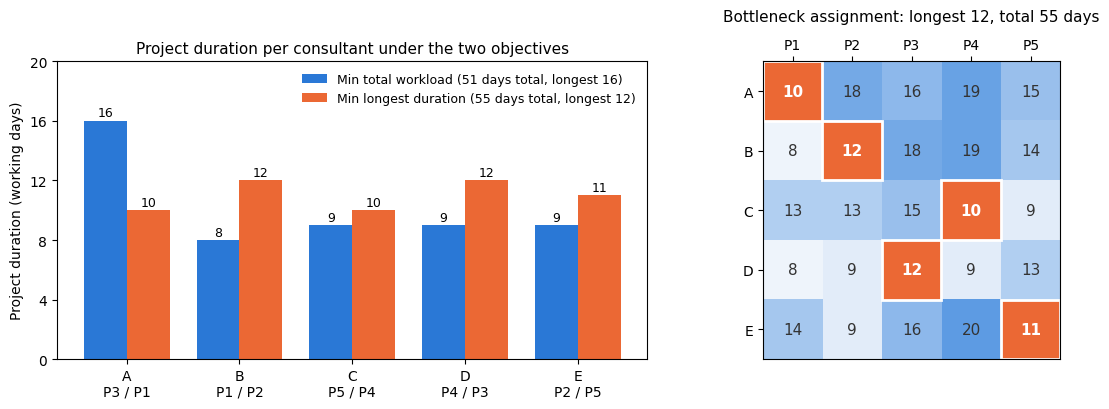

In [14]:
days_opt = [days[i, optimal[i][0]] for i in consultants]
days_bn = [days[i, assign_b[i][0]] for i in consultants]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={'width_ratios': [1.1, 1]})
w = 0.38
pos = range(len(consultants))
ax1.bar([p - w / 2 for p in pos], days_opt, w, color='#2a78d6', label=f'Min total workload ({sum(days_opt)} days total, longest {max(days_opt)})')
ax1.bar([p + w / 2 for p in pos], days_bn, w, color='#eb6834', label=f'Min longest duration ({sum(days_bn)} days total, longest {max(days_bn)})')
for p, (a, b) in enumerate(zip(days_opt, days_bn)):
    ax1.text(p - w / 2, a + 0.3, str(a), ha='center', fontsize=9)
    ax1.text(p + w / 2, b + 0.3, str(b), ha='center', fontsize=9)
ax1.set_xticks(list(pos))
ax1.set_xticklabels([f'{i}\n{optimal[i][0]} / {assign_b[i][0]}' for i in consultants])
ax1.set_ylabel('Project duration (working days)')
ax1.set_ylim(0, 20)
ax1.set_yticks(range(0, 21, 4))
ax1.set_title('Project duration per consultant under the two objectives', fontsize=11)
ax1.legend(frameon=False, fontsize=9)
plot_assignment(ax2, days, consultants, projects, assign_b, f'Bottleneck assignment: longest {max(days_bn)}, total {sum(days_bn)} days')
plt.tight_layout()
plt.show()

The two objectives lead to completely different plans. In the plan with the smallest total workload, A needs 16 days for P3 while the other four consultants need only 8 or 9 days, so the projects finish at very different times. The bottleneck plan keeps every duration between 10 and 12 days; the last project is finished on working day 12, four days earlier than in the original plan, at the price of raising the total workload from 51 to 55 days.

Which plan is better depends on the firm's goal. If projects are billed by the day and consultants can be released one by one to other work, the smallest total workload is the right choice; if the client requires all projects to be delivered together, the bottleneck assignment is. The model's contribution is to quantify the price of each choice, here 4 extra working days in exchange for finishing 4 days earlier, giving managers a concrete basis for the decision.